In [47]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , r2_score , root_mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler



In [30]:
df = pd.read_csv(r"..\dataset\student_data.csv")

X = df.drop("G3" , axis= 1)
y = df["G3"]

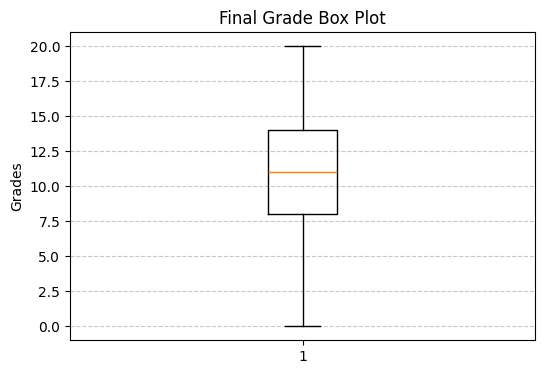

In [31]:
plt.figure(figsize=(6, 4))
plt.boxplot(y)

plt.title('Final Grade Box Plot')
plt.ylabel('Grades')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [40]:
categorical_columns = df.select_dtypes(include='object').columns

X_encoded = pd.get_dummies(X , columns= categorical_columns , dtype= int)

X_encoded.select_dtypes(include='object')

""
0
1
2
3
4
...
390
391
392
393


In [42]:
x_train , x_test , y_train , y_test = train_test_split(X_encoded , y , test_size= 0.2 , random_state= 48 , shuffle= True)

In [43]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)

X_test_scaled = scaler.transform(x_test)

In [46]:
LR_model = LinearRegression()

LR_model.fit(X_train_scaled , y_train)

y_pred = LR_model.predict(X_test_scaled)

y_pred


array([ 9.91960314,  9.66816588, 11.25717929,  8.67943341, 20.09297115,
       14.7532737 , 10.69926795, 10.23805204,  2.91460884,  6.65616507,
       17.02544636, 13.08174535,  6.50458456,  8.08002857,  8.5387411 ,
       16.17749416, 12.03027173, 12.47069975, 11.59924303, 11.29999424,
       20.25749563,  6.59935122, 10.87111968,  3.481618  , 10.08709113,
       12.0295807 , 15.03871251,  5.15314885, 11.09063702, -0.75549693,
        8.68075114,  8.78815143, 11.16842927, 11.76162322,  9.02883941,
        9.54924528,  8.86464995,  7.9679695 , 13.74424728, 11.6600537 ,
        0.87846412,  7.94982564,  7.30639768, 14.42513651,  3.94850216,
        7.33617993,  7.92689334, 13.7707704 ,  8.82935218, 10.51450178,
        8.05148881, 13.70306914, 19.00120645,  6.1101012 , 11.11284936,
       17.35338494, 10.91628321,  0.56402085,  8.28705478,  6.551596  ,
       18.38937296, 10.10330221, 10.47989145, 12.33321392, 12.55319092,
       11.51766746, 12.64216007, -0.31145361, 11.31928728, 12.08

In [48]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

In [49]:
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 1.22
MSE : 3.92
RMSE: 1.98
R²  : 0.8237


In [50]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred.round(2)
})

print(comparison.head(10))

   Actual  Predicted
0      10       9.92
1      10       9.67
2      11      11.26
3      10       8.68
4      19      20.09
5      15      14.75
6      10      10.70
7      10      10.24
8       0       2.91
9       6       6.66
